Based on the infamous jin yang 'is it a hotdog' from silicon valley I'm gonna do the same thing here.

Installing deps

In [1]:
!pip install -Uqq fastai ddgs

Declaring search image function

In [2]:
from ddgs import DDGS
from fastcore.all import *

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
import time, json


Downloading one example of hotdog

In [3]:
urls = search_images('hot dog photos', max_images=1)
urls[0]

'https://potatorolls.com/wp-content/uploads/2020/10/Basic-Hot-Dogs.jpg'

Downloading this hotdog image to test

We need to verify if the url is downloadable and cloudflare cdn doesn't stop us from downloading it

In [13]:
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor
import requests
from PIL import Image
from fastcore.all import *

def verify_url(url, timeout=5):
    """Test if URL is downloadable without protection"""
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
        response = requests.get(url, headers=headers, timeout=timeout, allow_redirects=True)

        if response.status_code == 200:
            Image.open(BytesIO(response.content))
            return True
        return False
    except:
        return False

def download_url_safe(url, dest):
    """Download with error handling"""
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        img = Image.open(BytesIO(response.content))
        img.save(dest)
        return True
    except Exception as e:
        print(f"Failed to download {url[:60]}...: {e}")
        return False

def search_images_verified_parallel(keywords, target_count=20, max_retries=5, batch_size=50):
    """Parallel version - much faster"""
    working_urls = L()
    retry_count = 0

    while len(working_urls) < target_count and retry_count < max_retries:
        print(f"\n🔍 Retry {retry_count + 1}/{max_retries}: Searching for {batch_size} images...")

        urls = search_images(keywords, max_images=batch_size)
        new_urls = L(url for url in urls if url not in working_urls)
        print(f"Testing {len(new_urls)} URLs in parallel...")

        with ThreadPoolExecutor(max_workers=10) as executor:
            results = list(executor.map(verify_url, new_urls))

        verified = L(url for url, valid in zip(new_urls, results) if valid)
        working_urls.extend(verified[:target_count - len(working_urls)])

        print(f"✓ Found {len(verified)} working URLs (Total: {len(working_urls)}/{target_count})")
        retry_count += 1

    return working_urls

# Usage - no need to verify again!
urls = search_images_verified_parallel('hot dog photos', target_count=20)
print(f"\nFinal: {len(urls)} verified working URLs")

# Download first one
if urls:
    download_url_safe(urls[0], 'hotdog.jpg')


🔍 Retry 1/5: Searching for 50 images...
Testing 50 URLs in parallel...
✓ Found 40 working URLs (Total: 20/20)

Final: 20 verified working URLs


In [17]:
print(f"\nFirst URL: {(urls[0])}") # --> cloudflare error when download
print(f"\nSecond URL: {(urls[1])}")




First URL: https://potatorolls.com/wp-content/uploads/2020/10/Basic-Hot-Dogs.jpg

Second URL: https://www.tasteofhome.com/wp-content/uploads/2019/04/Chicago-hot-dog_shutterstock_150836300.jpg


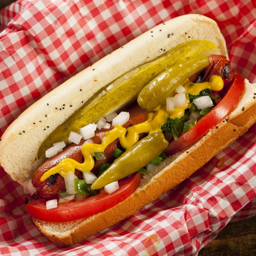

In [18]:
from fastdownload import download_url
dest = 'hotdog.jpg'
download_url(urls[1], dest, show_progress=True)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256, 256)

Now we are gonna compare it with forest photos

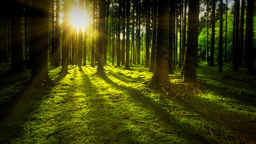

In [19]:
download_url(search_images('forest photos', max_images=1)[0], 'forest.jpg', show_progress=False)
Image.open('forest.jpg').to_thumb(256, 256)


Now lets grab forests and hotdogs and put each in a folder

In [20]:
searches = 'forest','hotdog'
path = Path('hotdog_or_not')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)


/Users/luskira/Documents/code/fastai-course-1/.venv/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


# Training the Model
Lets remove images that weren't downloaded correctly

In [21]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)


0

Now onto creating DataLoaders with the training set + validation set

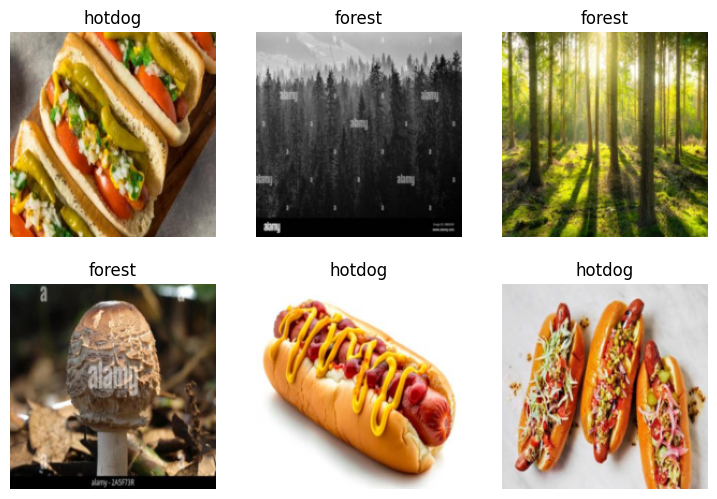

In [22]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6) # shows a small sample(batch = sample)


Finally let's run the vision_learner with resnet18 + fastai with fine_tune

In [23]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)


epoch,train_loss,valid_loss,error_rate,time
0,0.830500,0.010479,0.000000,00:06


epoch,train_loss,valid_loss,error_rate,time
0,0.173686,0.005540,0.000000,00:01
1,0.110660,0.003704,0.000000,00:00
2,0.072615,0.004768,0.000000,00:00


Now lets test the model with a hotdog image!

In [41]:
is_hotdog,_,probs = learn.predict(PILImage.create('hotdog.jpg'))
print(f"This is a: {is_hotdog}.")
print(f"Probability it's correct: {probs[0]:.4f}")


This is a: hotdog.
Probability it's correct: 0.0000


Now with a not hotdog image!(forest image)

In [27]:
is_hotdog,_,probs = learn.predict(PILImage.create('forest.jpg'))
print(f"This is a: {is_hotdog}.")
print(f"Probability it's correct: {probs[0]:.4f}")


This is a: forest.
Probability it's correct: 0.9988


Now just for the fun of it, lets give it a bird image and see what happens.

In [29]:
is_hotdog,_,probs = learn.predict(PILImage.create('bird.jpg'))
print(f"This is a: {is_hotdog}.")
print(f"Probability it's correct: {probs[0]:.4f}")


This is a: forest.
Probability it's correct: 0.9788
